In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv(
    r"C:\Users\hp\Downloads\archive (4)\twitter_training.csv",
    header=None,
    names=['tweet_id', 'entity', 'sentiment', 'text']
)

print("Before filtering:", df.shape)
print(df['sentiment'].value_counts())

# Drop Irrelevant rows — not a sentiment category, just "off-topic" flag
df = df[df['sentiment'] != 'Irrelevant'].copy()

# Also drop any rows with missing text (common in this dataset)
df = df.dropna(subset=['text'])

print("\nAfter filtering:", df.shape)
print(df['sentiment'].value_counts())

Before filtering: (74682, 4)
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

After filtering: (61121, 4)
sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


After removing the "Irrelevant" category (which flags off-topic tweets rather than representing a sentiment) and dropping rows with missing text, the dataset contains 61,121 tweets across three sentiment classes. The class distribution is fairly balanced across the three classes (Negative 36.6%, Positive 33.8%, Neutral 29.6%), so no severe class imbalance to worry about later. ~184 rows were dropped for missing text along the way, which is negligible against 61,121 total.

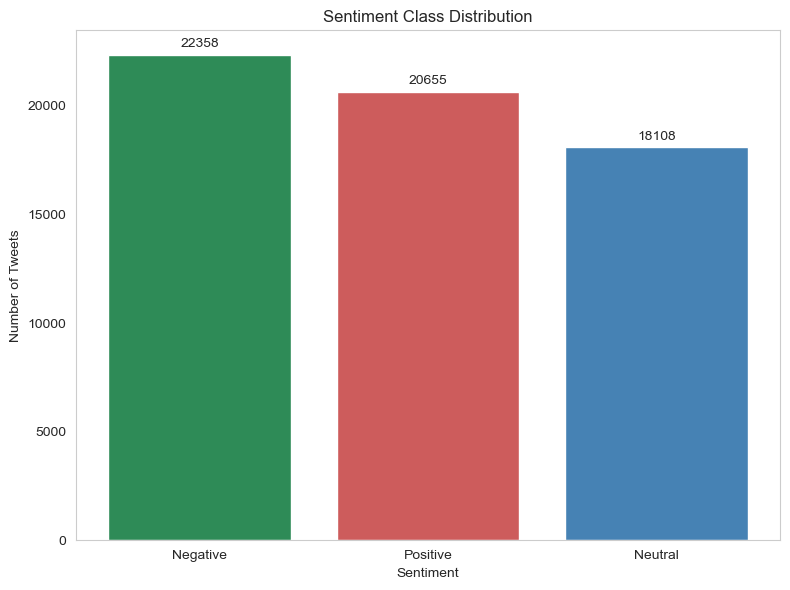

In [10]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8,6))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['seagreen','indianred','steelblue'])
plt.bar_label(bars, padding=3)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.grid(False)
plt.tight_layout()
plt.show()

In [11]:
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                              # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)             # remove URLs
    text = re.sub(r'@\w+', '', text)                       # remove @mentions
    text = re.sub(r'#', '', text)                          # remove hashtag symbol (keep the word)
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)                        # remove numbers
    tokens = word_tokenize(text)                            # tokenize
    tokens = [t for t in tokens if t not in stop_words]     # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]      # lemmatize
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

# Compare before/after on a few examples
df[['text', 'clean_text']].sample(5, random_state=1)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...


,text,clean_text
15472,2012 Its a great game when player shout each o...,great game player shout smile clipstwitchtvsil...
45922,In @verizon wrote a red Starbucks gift card I ...,wrote red starbucks gift card got verizonup sa...
34098,This is literally stupid a company that’s wort...,literally stupid company ’ worth ’ billion pet...
4404,Already cheating in @BlackOpsColdWar like come...,already cheating like come cant even decent pl...
42705,But mobile is easier???... It would be too easy.,mobile easier would easy


In [14]:
import unicodedata

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')  # strip smart quotes/emojis/accents
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].sample(5, random_state=1)

,text,clean_text
15472,2012 Its a great game when player shout each o...,great game player shout smile clipstwitchtvsil...
45922,In @verizon wrote a red Starbucks gift card I ...,wrote red starbucks gift card got verizonup sa...
34098,This is literally stupid a company that’s wort...,literally stupid company thats worth billion p...
4404,Already cheating in @BlackOpsColdWar like come...,already cheating like come cant even decent pl...
42705,But mobile is easier???... It would be too easy.,mobile easier would easy


An initial pass of the cleaning pipeline revealed that standard punctuation removal missed "smart" Unicode characters common in social media text (e.g. curly apostrophes '’' vs. straight apostrophes "'"), leaving stray characters in the cleaned output. This was fixed by normalizing Unicode text to plain ASCII before punctuation removal.

In [17]:
empty_after_cleaning = (df['clean_text'].str.strip() == '').sum()
print(f"Tweets that became empty after cleaning: {empty_after_cleaning}")

Tweets that became empty after cleaning: 1452


In [18]:
print("Before dropping empty rows:", df.shape)

df = df[df['clean_text'].str.strip() != ''].copy()

print("After dropping empty rows:", df.shape)
print(df['sentiment'].value_counts())

Before dropping empty rows: (61121, 5)
After dropping empty rows: (59669, 5)
sentiment
Negative    21891
Positive    20147
Neutral     17631
Name: count, dtype: int64


1,452 tweets (2.4%) became empty strings after preprocessing — these were typically very short tweets consisting only of URLs, mentions, numbers, or stopwords with no remaining content after cleaning. These rows were dropped since they contain no usable text features for the model. This left 59669 tweets across the three sentiment classes.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (59669, 5000)


purpose of TF-IDF: TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical features that a machine learning model can use. It scores each word in a tweet based on how frequently it appears in that tweet (Term Frequency) offset by how common that word is across all tweets (Inverse Document Frequency) — so common, uninformative words (even ones stopword removal missed) get down-weighted, while distinctive words that help discriminate between sentiment classes get more weight. This is preferred over simple word counts (Bag of Words) because it accounts for word importance, not just raw frequency. max_features=5000 limits the vocabulary to the 5,000 most informative terms to keep the model efficient; min_df=5 ignores extremely rare words (likely typos or noise); max_df=0.8 ignores words appearing in over 80% of tweets (too common to be discriminative).

In [20]:
#Train/test split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train size: 47735
Test size: 11934

Train class distribution:
sentiment
Negative    0.367
Positive    0.338
Neutral     0.295
Name: proportion, dtype: float64

Test class distribution:
sentiment
Negative    0.367
Positive    0.338
Neutral     0.295
Name: proportion, dtype: float64


The data was split 80/20 into training and test sets, using stratified sampling (stratify=y) to ensure both sets preserve the same class proportions as the full dataset — important given the classes weren't perfectly balanced to begin with.

In [21]:
#Train two classifiers — Naive Bayes + Logistic Regression
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Both models trained.")

Both models trained.


Two classifiers were trained for comparison: Multinomial Naive Bayes, a fast probabilistic model commonly used as a strong baseline for text classification, and Logistic Regression, a linear model that often performs well on high-dimensional sparse data like TF-IDF vectors. Comparing a simple probabilistic model against a linear discriminative model gives insight into which approach better captures the sentiment patterns in this dataset.

=== Naive Bayes ===
Accuracy: 0.7227
              precision    recall  f1-score   support

    Negative       0.72      0.81      0.76      4378
     Neutral       0.74      0.56      0.64      3526
    Positive       0.72      0.77      0.74      4030

    accuracy                           0.72     11934
   macro avg       0.72      0.71      0.71     11934
weighted avg       0.72      0.72      0.72     11934



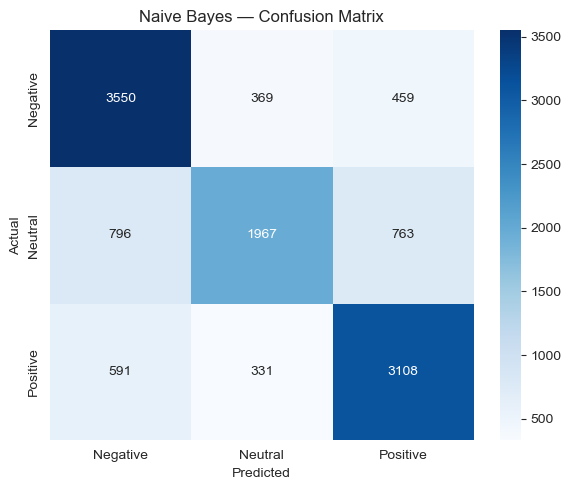

=== Logistic Regression ===
Accuracy: 0.7644
              precision    recall  f1-score   support

    Negative       0.79      0.81      0.80      4378
     Neutral       0.73      0.68      0.70      3526
    Positive       0.77      0.79      0.78      4030

    accuracy                           0.76     11934
   macro avg       0.76      0.76      0.76     11934
weighted avg       0.76      0.76      0.76     11934



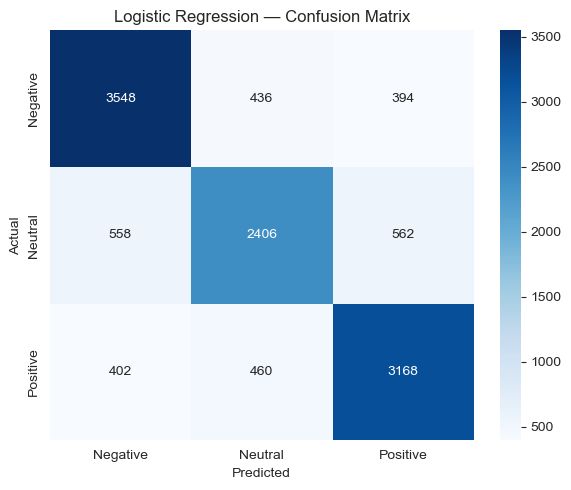

In [22]:
#Evaluation — accuracy, precision, recall, F1, confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(name, y_true, y_pred, labels):
    print(f"=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

labels = ['Negative', 'Neutral', 'Positive']

evaluate_model("Naive Bayes", y_test, nb_preds, labels)
evaluate_model("Logistic Regression", y_test, lr_preds, labels)

Model Comparison: Logistic Regression outperformed Naive Bayes on every metric: overall accuracy (76.4% vs. 72.3%), and F1-score on all three classes (Negative: 0.80 vs. 0.76; Neutral: 0.70 vs. 0.64; Positive: 0.78 vs. 0.74). The gap is largest on the Neutral class, where Naive Bayes only recalled 56% of actual neutral tweets (missing 44% of them) compared to 68% for Logistic Regression.

Both models share the same underlying weakness: Neutral is by far the hardest class to predict correctly, and it's confused with both Negative and Positive at meaningfully higher rates than Negative and Positive are confused with each other. In the Naive Bayes matrix, 796 true-Neutral tweets were misclassified as Negative and 763 as Positive — a combined 44% of all Neutral tweets. This pattern makes intuitive sense: neutral sentiment is inherently more ambiguous in short, informal text like tweets, where sarcasm, mild complaints, or factual statements can easily read as leaning positive or negative depending on word choice, while genuinely negative or positive tweets tend to use more clearly polarized language that's easier for a bag-of-words-style model to pick up on.

Notably, Logistic Regression's improvement over Naive Bayes is concentrated almost entirely in fixing this Neutral-class confusion (recall jumped from 56% to 68%), while its performance on Negative and Positive was only modestly better. This suggests Logistic Regression's ability to weigh combinations of words (rather than treating each word's contribution independently, as Naive Bayes does) is specifically what helps it catch subtler, less polarized language — which is exactly where Naive Bayes' independence assumption breaks down.

In [24]:
!pip install wordcloud

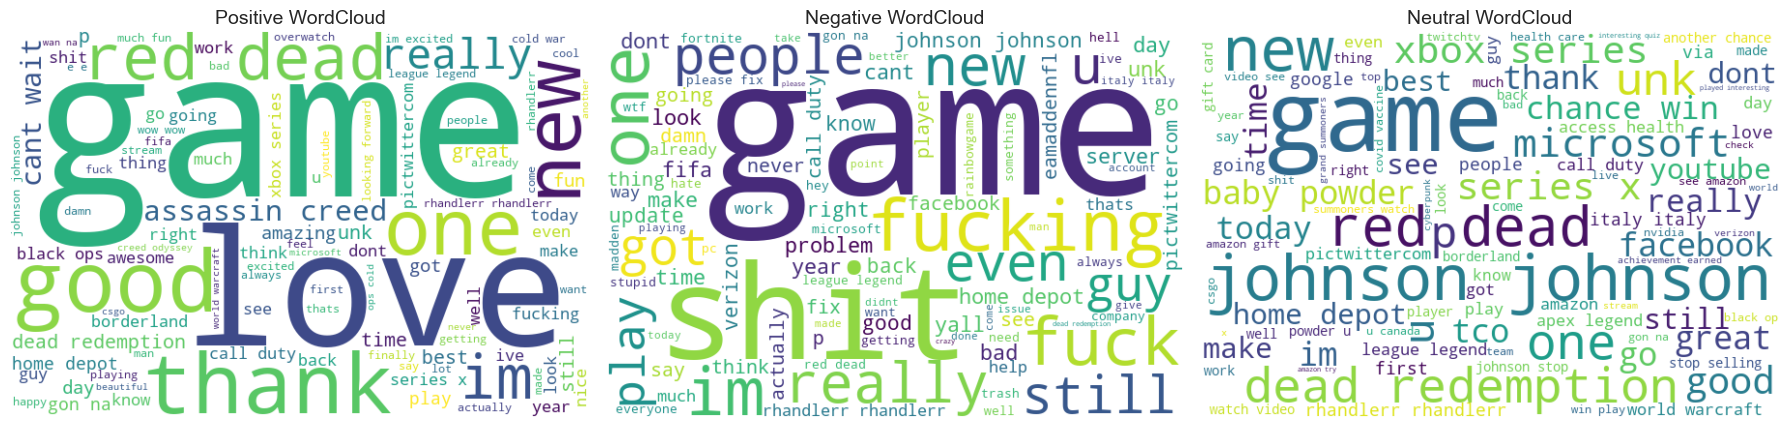

In [25]:
#WordClouds per sentiment class
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
    text = ' '.join(df[df['sentiment'] == sentiment]['clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white', max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"{sentiment} WordCloud", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

WordCloud analysis: "Game" dominates all three classes similarly, reflecting that this dataset is drawn from gaming/tech-related tweets (entities like Borderlands, Call of Duty, FIFA, Red Dead Redemption, Xbox) regardless of sentiment — this shared vocabulary is exactly why TF-IDF's document-frequency weighting matters, since generic domain words get down-weighted relative to more sentiment-specific terms.

The Positive class shows genuinely emotional, sentiment-bearing words — "love," "thank," "good," "awesome," "great" — words that clearly signal positive sentiment on their own. The Negative class is dominated by profanity and complaint language ("shit," "fucking," "problem," "fix," "hate") — also clearly polarized and easy to key off of.

The Neutral class tells a different story: instead of sentiment-bearing words, it's dominated by brand and entity names — "Microsoft," "Xbox," "Johnson," "Amazon," "Verizon," "Google" — along with neutral factual language like "series," "today," "release." This is a strong non-obvious insight: Neutral tweets aren't neutral because they use "moderate" emotional language — they're neutral because they're largely informational or factual statements about a product/brand rather than opinions at all. This explains why both models struggled most with this class: there's no consistent emotional vocabulary for the model to learn, since "neutral" here really means "absence of sentiment-bearing language" rather than a distinct emotional tone of its own — making it inherently harder to separate from mildly-worded positive or negative tweets using word-frequency-based features like TF-IDF.

In [26]:
#Error Analysis — 5 misclassified examples

# Rebuild a test dataframe with original text alongside predictions, using the best model (Logistic Regression)
test_indices = y_test.index
error_df = df.loc[test_indices].copy()
error_df['predicted'] = lr_preds
error_df['actual'] = y_test.values

misclassified = error_df[error_df['predicted'] != error_df['actual']]

print(f"Total misclassified: {len(misclassified)} out of {len(error_df)} ({len(misclassified)/len(error_df)*100:.1f}%)")

# Sample 5 misclassified examples
sample_errors = misclassified[['text', 'clean_text', 'actual', 'predicted']].sample(5, random_state=42)
pd.set_option('display.max_colwidth', None)
sample_errors

Total misclassified: 2812 out of 11934 (23.6%)


,text,clean_text,actual,predicted
10297,"As one of the few current Next-Gen Exclusives, this looks really good, even if it's not for me... 13 Minutes Of Exclusive 4K Xbox Series X Scorn Gameplay youtu.be / 6grwdMemV1o via @ YouTube",one current nextgen exclusive look really good even minute exclusive k xbox series x scorn gameplay youtube grwdmemvo via youtube,Positive,Neutral
25651,I miss stuff like that in Assassin's Creed.. store.playstation.com /,miss stuff like assassin creed storeplaystationcom,Negative,Positive
37396,DB I do like this hearthstone pic.twitter.com/ef2LVsY44m,db like hearthstone pictwittercomeflvsym,Positive,Neutral
41822,Morning all... Today's itinerary. Make my roots and dye my hair. Long hot bath with bubbles (from hell itself). Be one with the universen't shit. Who am I to ski with the last one. Play some Titanfall. Play Battlefield 1. Take some photos. Web work https: / / Fenco / JHT11pwm8T,morning today itinerary make root dye hair long hot bath bubble hell one universent shit ski last one play titanfall play battlefield take photo web work fenco jhtpwmt,Positive,Neutral
25807,It is not the first time that the EU Commission has taken such a step.,first time eu commission taken step,Negative,Neutral


## Conclusion

**Best-performing model:** Logistic Regression outperformed Multinomial Naive Bayes across every metric (76.4% vs. 72.3% accuracy, and higher F1-score on all three classes). The advantage was concentrated specifically in correctly identifying Neutral tweets, where Logistic Regression's ability to weigh combinations of words — rather than treating each word independently, as Naive Bayes does — better captured the subtler, less polarized language typical of neutral/factual statements.

**Key finding:** Neutral sentiment was consistently the hardest class for both models, not because neutral language is inherently harder to spot, but because — as the WordCloud and error analysis both showed — "neutral" tweets are largely factual or brand/product-related statements defined by an *absence* of sentiment language, rather than a distinct emotional tone of their own. This makes them structurally harder to separate from mildly-worded positive or negative tweets using word-frequency-based features.

**Real-world application:** This kind of model could power a brand/product monitoring dashboard — for example, a gaming company tracking public sentiment toward game releases or platform announcements in real time on social media, flagging spikes in negative sentiment (e.g. after a bad patch or server outage) for customer support or PR teams to respond to quickly. Given the model's specific weakness on the Neutral class, such a system would be most reliable as an early-warning tool for clearly negative sentiment spikes, while treating "Neutral" predictions with more caution, and potentially routing borderline/low-confidence predictions to human review rather than trusting the automated label outright.